# Chapter 3 Practical 01: User-Item Matrix and Sparsity

Learning objectives:
- Build a user-item rating matrix from interactions.
- Measure density and sparsity.
- Understand why collaborative filtering needs overlap.
- Visualize rating distributions and missing values.

Slide connection: collaborative filtering motivation, memory-based CF overview, and user-item rating matrix.


In [1]:
# Teaching note: Load ratings and movies with a Colab-safe fallback. Local files are used first; GitHub raw CSVs are used when opened directly from GitHub.
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIRS = [
    Path("data"),
    Path("../data"),
    Path("chapter_03_collaborative_filtering/data"),
]
GITHUB_DATA_URL = "https://raw.githubusercontent.com/MehrdadJalali-AI/RecommenderSystems/main/chapter_03_collaborative_filtering/data"

def read_chapter3_csv(filename):
    for data_dir in DATA_DIRS:
        csv_path = data_dir / filename
        if csv_path.exists():
            print(f"Loaded {filename} from {csv_path}")
            return pd.read_csv(csv_path)
    url = f"{GITHUB_DATA_URL}/{filename}"
    print(f"Local file not found. Loading {filename} from GitHub raw URL.")
    return pd.read_csv(url)

ratings = read_chapter3_csv("ratings_chapter3.csv")
movies = read_chapter3_csv("movies_chapter3.csv")
ratings_named = ratings.merge(movies, on="movie_id", how="left")
# Pivot interactions into rows = users and columns = items.
rating_matrix = ratings_named.pivot_table(index="user_id", columns="title", values="rating")
rating_matrix


Loaded ratings_chapter3.csv from data/ratings_chapter3.csv
Loaded movies_chapter3.csv from data/movies_chapter3.csv


title,Blade Runner,Finding Nemo,Independence Day,Jurassic Park,Star Wars,Terminator 2,The Matrix,The Notebook,Titanic,Toy Story
user_id,,,,,,,,,,
Alice,5.0,NaN,4.0,NaN,4.0,NaN,5.0,NaN,NaN,NaN
Bob,NaN,NaN,6.0,4.0,7.0,4.0,7.0,NaN,NaN,NaN
Chris,NaN,NaN,2.0,7.0,3.0,7.0,NaN,NaN,NaN,5.0
Karen,NaN,NaN,NaN,4.0,7.0,3.0,6.0,NaN,NaN,NaN
Lynn,NaN,NaN,2.0,4.0,4.0,6.0,NaN,NaN,NaN,6.0
Nina,NaN,5.0,NaN,4.0,NaN,NaN,NaN,NaN,2.0,5.0
Omar,NaN,2.0,NaN,3.0,NaN,NaN,NaN,5.0,5.0,NaN
Sally,NaN,NaN,7.0,6.0,7.0,3.0,6.0,NaN,NaN,NaN


Memory-based CF keeps the interaction matrix and uses it directly at recommendation time.


In [2]:
# Teaching note: Calculate density and sparsity to show why missing values dominate CF data.
n_users, n_items = rating_matrix.shape
n_known = rating_matrix.notna().sum().sum()
density = n_known / (n_users * n_items)

summary = pd.DataFrame({
    "measure": ["users", "items", "known ratings", "possible ratings", "density", "sparsity"],
    "value": [n_users, n_items, n_known, n_users * n_items, round(density, 3), round(1 - density, 3)],
})
summary


,measure,value
0,users,8.00
1,items,10.00
2,known ratings,36.00
3,possible ratings,80.00
4,density,0.45
5,sparsity,0.55


Missing values are not zero ratings. They mean unknown preference.


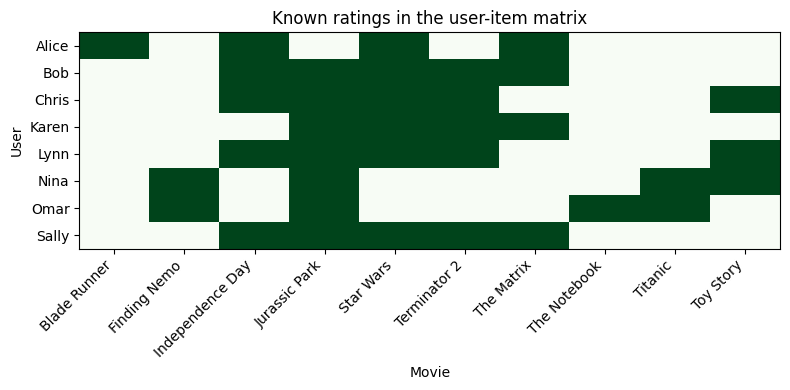

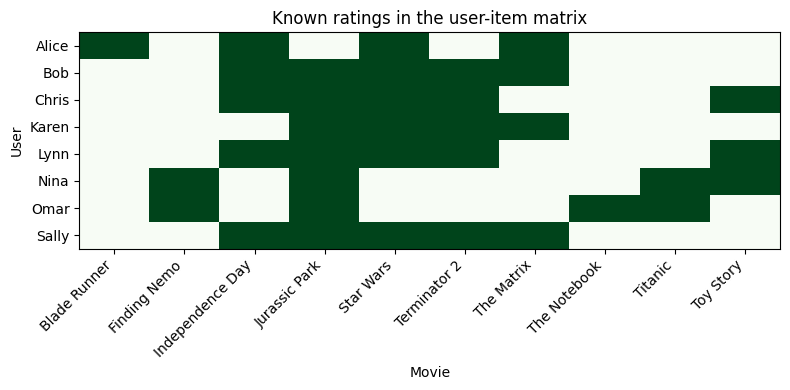

In [3]:
# Teaching note: Visualize known ratings; blank cells represent unknown preferences, not zeros.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(rating_matrix.notna(), aspect="auto", cmap="Greens")
ax.set_xticks(range(len(rating_matrix.columns)), rating_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(rating_matrix.index)), rating_matrix.index)
ax.set_title("Known ratings in the user-item matrix")
ax.set_xlabel("Movie")
ax.set_ylabel("User")
fig.tight_layout()
fig


The number of co-rated items determines how trustworthy a user-user comparison can be.


In [4]:
# Teaching note: Count co-rated items between every user pair to measure overlap.
users = rating_matrix.index
overlap = pd.DataFrame(index=users, columns=users, dtype=int)
for u in users:
    for v in users:
        overlap.loc[u, v] = rating_matrix.loc[[u, v]].notna().all(axis=0).sum()
overlap


user_id,Alice,Bob,Chris,Karen,Lynn,Nina,Omar,Sally
user_id,,,,,,,,
Alice,4.0,3.0,2.0,2.0,2.0,0.0,0.0,3.0
Bob,3.0,5.0,4.0,4.0,4.0,1.0,1.0,5.0
Chris,2.0,4.0,5.0,3.0,5.0,2.0,1.0,4.0
Karen,2.0,4.0,3.0,4.0,3.0,1.0,1.0,4.0
Lynn,2.0,4.0,5.0,3.0,5.0,2.0,1.0,4.0
Nina,0.0,1.0,2.0,1.0,2.0,4.0,3.0,1.0
Omar,0.0,1.0,1.0,1.0,1.0,3.0,4.0,1.0
Sally,3.0,5.0,4.0,4.0,4.0,1.0,1.0,5.0


In [5]:
# Teaching note: Summarize item popularity and average rating as simple baseline signals.
# Groupby aggregates ratings by user or item for summary statistics.
ratings_named.groupby("title")["rating"].agg(["count", "mean"]).sort_values(["count", "mean"], ascending=False)


,count,mean
title,,
Jurassic Park,7,4.571429
Star Wars,6,5.333333
Terminator 2,5,4.600000
Independence Day,5,4.200000
The Matrix,4,6.000000
Toy Story,3,5.333333
Finding Nemo,2,3.500000
Titanic,2,3.500000
Blade Runner,1,5.000000


## Challenge Lab

1. Add a new user with exactly one rating, rebuild the user-item matrix, and recompute density and sparsity. Explain why this user is difficult for collaborative filtering.
2. Find the pair of users with the largest number of co-rated movies. Compare their actual ratings on those movies and decide whether overlap alone is enough to call them similar.
